#Exploracion de datos

--- ESTRUCTURA GENERAL DE VARIABLES Y TIPOS ---
                       Tipo de Dato  Valores No Nulos  Valores Nulos  Porcentaje Nulos (%)
video_id                     object             23378              0                  0.00
trending_date                object             23378              0                  0.00
title                        object             23378              0                  0.00
channel_title                object             23378              0                  0.00
category_id                   int64             23378              0                  0.00
publish_time                 object             23378              0                  0.00
tags                         object             23378              0                  0.00
views                         int64             23378              0                  0.00
likes                         int64             23378              0                  0.00
dislikes                      int64       

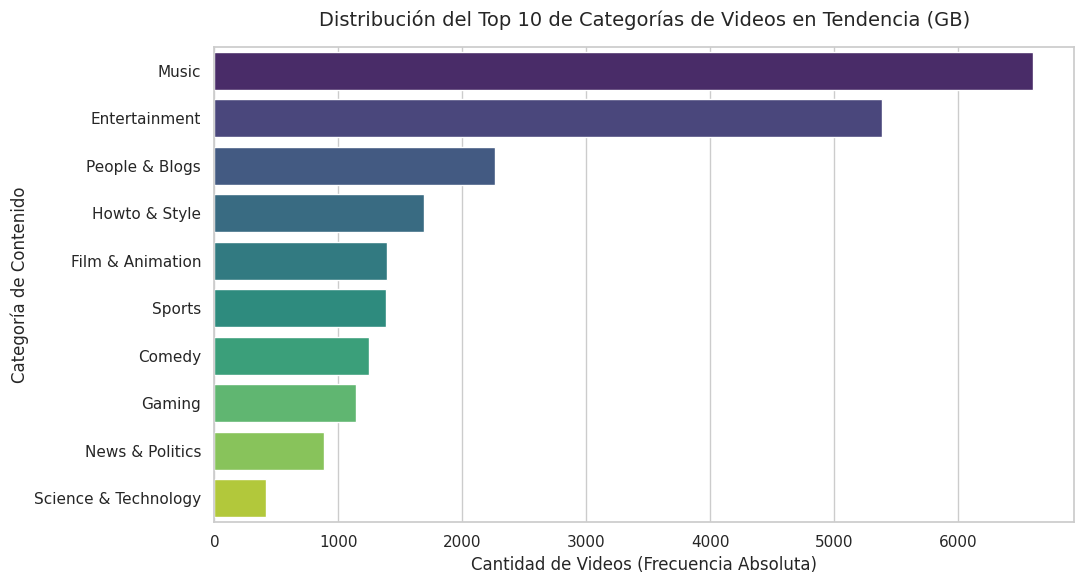

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# A. CARGA DE LOS DATOS
# ==========================================
df = pd.read_csv("GBvideos_cc50_202101.csv")

with open("GB_category_id.json", "r") as f:
    categories_data = json.load(f)

# Conversión y mapeo jerárquico del archivo JSON externo
category_map = {
    int(item["id"]): item["snippet"]["title"] for item in categories_data["items"]
}
df["category_name"] = df["category_id"].map(category_map).fillna("Unknown")

# ==========================================
# B. INSPECCIÓN DE LOS DATOS
# ==========================================
print("--- ESTRUCTURA GENERAL DE VARIABLES Y TIPOS ---")
info_estructura = pd.DataFrame(
    {
        "Tipo de Dato": df.dtypes.astype(str),
        "Valores No Nulos": df.notnull().sum(),
        "Valores Nulos": df.isnull().sum(),
        "Porcentaje Nulos (%)": (df.isnull().sum() / len(df) * 100).round(2),
    }
)
print(info_estructura.to_string())

print("\n--- ESTADÍSTICA DESCRIPTIVA (MÉTRICAS) ---")
metricas = ["views", "likes", "dislikes", "comment_count", "lat", "lon"]
print(df[metricas].describe().round(2).to_string())

print("\n--- TABLA DE FRECUENCIA DE CATEGORÍAS ---")
freq_table = df["category_name"].value_counts().reset_index()
freq_table.columns = ["Categoría", "Frecuencia Absoluta"]
freq_table["Frecuencia Relativa (%)"] = (
    freq_table["Frecuencia Absoluta"] / len(df) * 100
).round(2)
print(freq_table.to_string(index=False))

# ==========================================
# C. VISUALIZACIÓN DE LOS DATOS
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

sns.barplot(
    data=freq_table.head(10),
    x="Frecuencia Absoluta",
    y="Categoría",
    palette="viridis",
    hue="Categoría",
    legend=False,
)

plt.title(
    "Distribución del Top 10 de Categorías de Videos en Tendencia (GB)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Cantidad de Videos (Frecuencia Absoluta)", fontsize=12)
plt.ylabel("Categoría de Contenido", fontsize=12)
plt.tight_layout()

plt.savefig("top_categories_reporte.png", dpi=300)
print("\n[INFO] Visualización exportada con éxito.")

## Verificacion de datos

Cantidad y Distribución de Valores Nulos (Completitud)

In [ ]:
nulos_resumen = pd.DataFrame(
    {
        "Cantidad Nulos": df.isnull().sum(),
        "Porcentaje Nulos (%)": (df.isnull().sum() / len(df) * 100).round(2),
    }
)
print(nulos_resumen[nulos_resumen["Cantidad Nulos"] > 0])

             Cantidad Nulos  Porcentaje Nulos (%)
description             612                  1.57


Consistencia de valores individuales (Logica de Negocio)

In [ ]:
inconsistencia_likes = df[df["likes"] > df["views"]].shape[0]
inconsistencia_dislikes = df[df["dislikes"] > df["views"]].shape[0]
fuera_coordenadas = df[
    (df["lat"] < 49)
    | (df["lat"] > 61)
    | (df["lon"] < -9)
    | (df["lon"] > 2)
].shape[0]

print(f"Likes mayores a vistas: {inconsistencia_likes}")
print(f"Dislikes mayores a vistas: {inconsistencia_dislikes}")
print(f"Coordenadas fuera del Reino Unido: {fuera_coordenadas}")

Likes mayores a vistas: 0
Dislikes mayores a vistas: 0
Coordenadas fuera del Reino Unido: 0


Valores Fuera de Rango y Ruido (Outliers)

In [ ]:
metricas = ["views", "likes", "dislikes", "comment_count"]

for col in metricas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr

    outliers = df[df[col] > limite_superior].shape[0]
    pct = round((outliers / len(df)) * 100, 2)
    print(
        f"Variable '{col}': Umbral Superior Máximo = {limite_superior:.2f} | Outliers Detectados = {outliers} ({pct}%)"
    )

Variable 'views': Umbral Superior Máximo = 8831780.38 | Outliers Detectados = 5308 (13.64%)
Variable 'likes': Umbral Superior Máximo = 276377.62 | Outliers Detectados = 4696 (12.07%)
Variable 'dislikes': Umbral Superior Máximo = 8093.75 | Outliers Detectados = 5639 (14.49%)
Variable 'comment_count': Umbral Superior Máximo = 22085.25 | Outliers Detectados = 4915 (12.63%)
